# Resolução - Exercícios 1.1 e 1.2

Este notebook contém a implementação da dedução analítica da disponibilidade e a simulação estocástica para os exercícios da disciplina de Computação Distribuída.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb, ceil

# Configuração visual para os gráficos
plt.style.use('seaborn-v0_8-darkgrid')

### Implementação do Modelo Analítico e do Simulador

Abaixo definimos duas funções. A função analítica utiliza `math.comb` para a distribuição binomial. A função simulada utiliza matrizes do `numpy` para gerar todas as 10.000 rodadas simultaneamente, garantindo alta performance.

In [2]:
def disp_analitica(n, k, p):
    """Calcula a disponibilidade usando a fórmula binomial."""
    disponibilidade = sum(comb(n, i) * (p**i) * ((1-p)**(n-i)) for i in range(k, n + 1))
    return disponibilidade

def disp_simulada(n, k, p, rodadas=10000):
    """Executa o simulador estocástico vetorizado."""
    sorteios = np.random.rand(rodadas, n) <= p
    servidores_ativos_por_rodada = np.sum(sorteios, axis=1)
    sucessos = servidores_ativos_por_rodada >= k
    return np.mean(sucessos)

In [3]:
n_valores = [3, 5, 10, 20, 50]
p_valores = [0.1, 0.5, 0.75, 0.9, 0.99]

regras_k = {
    'k=1 (Consulta)': lambda n: 1,
    'k=ceil(n/2) (Maioria)': lambda n: ceil(n / 2),
    'k=n (Atualização)': lambda n: n
}

resultados = []

for n in n_valores:
    for nome_regra, calc_k in regras_k.items():
        k = calc_k(n)
        for p in p_valores:
            analitico = disp_analitica(n, k, p)
            simulado = disp_simulada(n, k, p)
            diferenca = abs(analitico - simulado)
            
            resultados.append({
                'n': n,
                'k': k,
                'Regra': nome_regra,
                'p': p,
                'Analítico': analitico,
                'Simulado': simulado,
                'Dif. Absoluta': diferenca
            })

df = pd.DataFrame(resultados)
df_display = df.style.format({
    'Analítico': '{:.6f}', 
    'Simulado': '{:.6f}', 
    'Dif. Absoluta': '{:.6f}'
})
df_display

,n,k,Regra,p,Analítico,Simulado,Dif. Absoluta
0,3,1,k=1 (Consulta),0.100000,0.271000,0.268800,0.002200
1,3,1,k=1 (Consulta),0.500000,0.875000,0.875100,0.000100
2,3,1,k=1 (Consulta),0.750000,0.984375,0.984400,0.000025
3,3,1,k=1 (Consulta),0.900000,0.999000,0.998800,0.000200
4,3,1,k=1 (Consulta),0.990000,0.999999,1.000000,0.000001
5,3,2,k=ceil(n/2) (Maioria),0.100000,0.028000,0.029500,0.001500
6,3,2,k=ceil(n/2) (Maioria),0.500000,0.500000,0.498700,0.001300
7,3,2,k=ceil(n/2) (Maioria),0.750000,0.843750,0.841800,0.001950
8,3,2,k=ceil(n/2) (Maioria),0.900000,0.972000,0.974600,0.002600
9,3,2,k=ceil(n/2) (Maioria),0.990000,0.999702,0.999400,0.000302


### Visualização dos Resultados (Gráficos 2D)
Abaixo plotamos dois cenários distintos para evidenciar como a disponibilidade do sistema se comporta, conforme solicitado no Exercício 1.2.

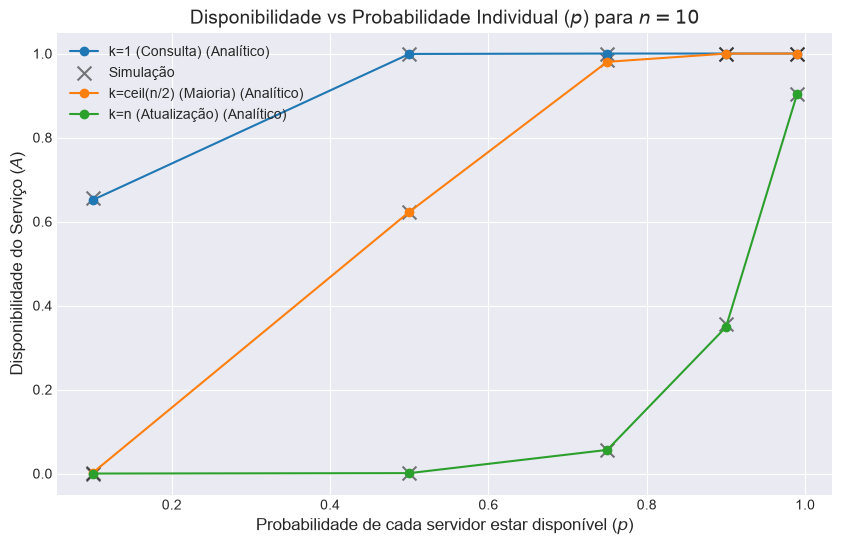

In [4]:
n_fixo = 10
df_n10 = df[df['n'] == n_fixo]

plt.figure(figsize=(10, 6))

for regra in df_n10['Regra'].unique():
    dados = df_n10[df_n10['Regra'] == regra]
    plt.plot(dados['p'], dados['Analítico'], marker='o', label=f'{regra} (Analítico)')
    plt.scatter(dados['p'], dados['Simulado'], marker='x', s=100, color='black', alpha=0.5, label=f'Simulação')

plt.title(f'Disponibilidade vs Probabilidade Individual ($p$) para $n={n_fixo}$', fontsize=14)
plt.xlabel('Probabilidade de cada servidor estar disponível ($p$)', fontsize=12)
plt.ylabel('Disponibilidade do Serviço ($A$)', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.ylim(-0.05, 1.05)
plt.show()

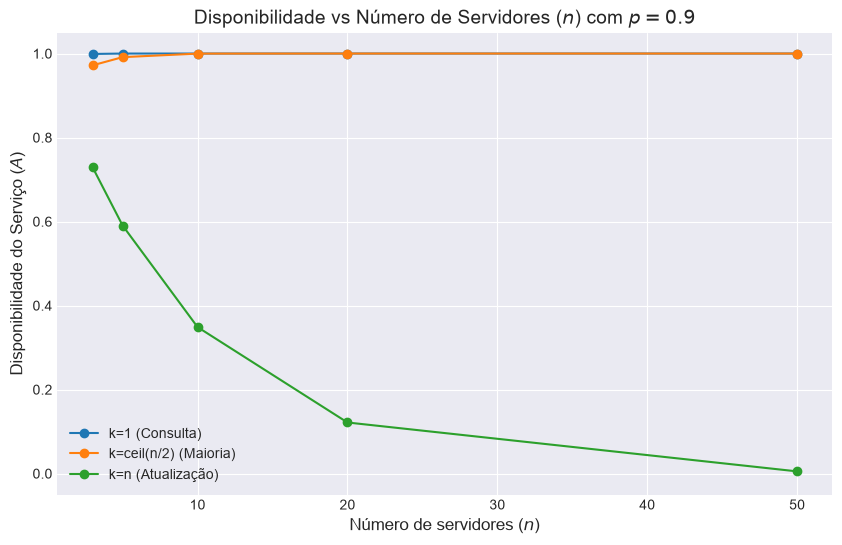

In [5]:
p_fixo = 0.90
df_p90 = df[df['p'] == p_fixo]

plt.figure(figsize=(10, 6))

for regra in df_p90['Regra'].unique():
    dados = df_p90[df_p90['Regra'] == regra]
    plt.plot(dados['n'], dados['Analítico'], marker='o', label=f'{regra}')

plt.title(f'Disponibilidade vs Número de Servidores ($n$) com $p={p_fixo}$', fontsize=14)
plt.xlabel('Número de servidores ($n$)', fontsize=12)
plt.ylabel('Disponibilidade do Serviço ($A$)', fontsize=12)
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()